In [ ]:
import torch
from torchvision import datasets, transforms
data_dir = "./data"


transform = transforms.ToTensor()
trainset = datasets.MNIST(
    root=data_dir, 
    train=True,
    download=True,
    transform=transform
    )

testset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

In [35]:
all_images_train = torch.stack([trainset[i][0] for i in range(len(trainset))])
all_images_test = torch.stack([testset[i][0] for i in range(len(testset))])

#Calculate mean and std of the training and test datasets, for normalizaton

mean_train = all_images_train.mean().item()
std_train = all_images_train.std().item()
print(f"all_images_train - Media: {mean_train:.4f}, Std: {std_train:.4f}")

mean_test = all_images_test.mean().item()
std_test = all_images_test.std().item()
print(f"all_images_test - Media: {mean_test:.4f}, Std: {std_test:.4f}")

all_images_train - Media: 0.1307, Std: 0.3081
all_images_test - Media: 0.1325, Std: 0.3105


# Loading data

Loading data:
    - test
    - seed

Using compose to transform the data:
    . To tensor: 
        to convert the datasets into a tensor
    . Normalization
        

In [36]:

from torchvision import datasets, transforms

data_dir = "./data"


transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((mean_test,), (std_test,))
    ])

trainset = datasets.MNIST(
        root=data_dir,
        train=True,
        download=True,
        transform=transform
    )

testset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

In [37]:
def images_extractor(dataset):
    """
    Extrae las imágenes y etiquetas de un dataset de MNIST,
    y las devuelve como arrays de numpy.
    """
    images =  torch.stack([dataset[i][0] for i in range(len(dataset))])
    return images.numpy()


def labels_extractor(dataset):
    """
    Extrae las imágenes y etiquetas de un dataset de MNIST,
    y las devuelve como arrays de numpy.
    """
    labels = torch.tensor([dataset[i][1] for i in range(len(dataset))])
    return labels.numpy()

In [ ]:
test_images = images_extractor(testset)
test_labels = labels_extractor(testset)

# Statistics 

## Mean and STD are suppose to be 0 an 1 since they are normalized. 

# Expected results after trainng

In [39]:

import numpy as np

print(f"mean = {test_images.mean():.4f}, std = {test_images.std():.4f}")

unique_t, counts_t = np.unique(test_labels, return_counts=True)

print("\nDistribution in TEST:")
for d, c in zip(unique_t, counts_t):
    print(f"  Digit {d}: {c} images")


mean = -0.0000, std = 1.0000

Distribution in TEST:
  Digit 0: 980 images
  Digit 1: 1135 images
  Digit 2: 1032 images
  Digit 3: 1010 images
  Digit 4: 982 images
  Digit 5: 892 images
  Digit 6: 958 images
  Digit 7: 1028 images
  Digit 8: 974 images
  Digit 9: 1009 images


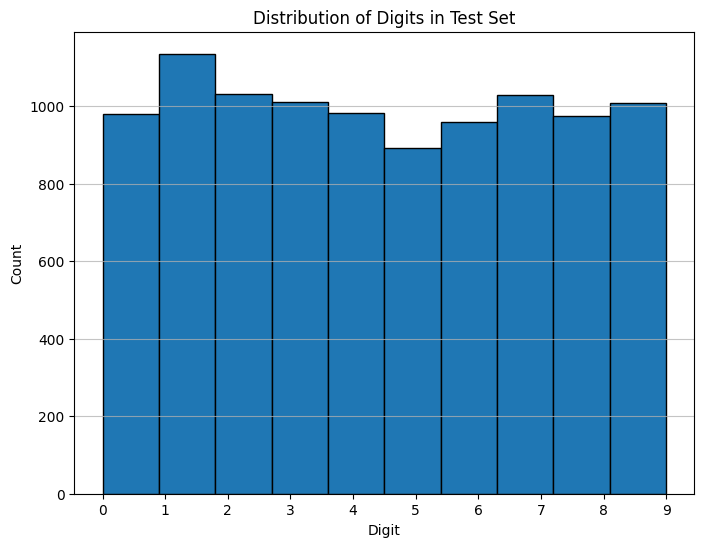

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(test_labels, edgecolor='black')
plt.xticks(range(10))
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Distribution of Digits in Test Set')
plt.grid(axis='y', alpha=0.75)
plt.savefig('../output/digit_distribution.png', dpi=150)
plt.show()


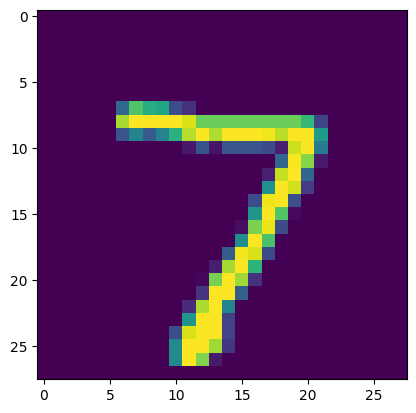

In [41]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(test_images[0,0])
plt.show()

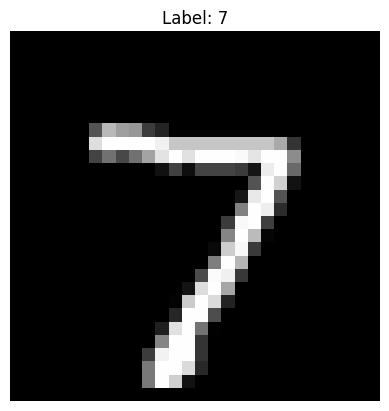

In [42]:
import matplotlib.pyplot as plt

plt.imshow(test_images[0, 0], cmap='gray')
plt.title(f"Label: {test_labels[0]}")
plt.axis('off')
plt.savefig(f'../output/sample_image_label_{test_labels[0]}.png', dpi=150)
plt.show()


(10000, 1, 28, 28)


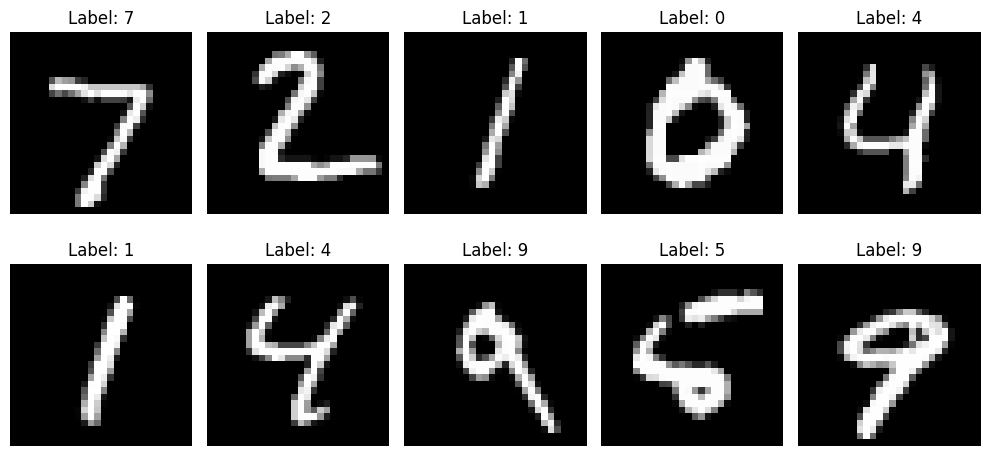

In [43]:
import matplotlib.pyplot as plt

print(test_images.shape)   

# test_images' shape is (N, 1, 28, 28)
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = test_images[i, 0] if test_images.ndim == 4 else test_images[i]
    img_display = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img_display, cmap='gray')
    ax.set_title(f"Label: {test_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('../output/sample_images.png', dpi=150)
plt.show()

# Modeling 
Definingn a Convolutional neural network (cnn)

In [44]:
test_images_cnn = test_images.reshape((-1, 28, 28, 1))
print(test_images_cnn.shape)

(10000, 28, 28, 1)


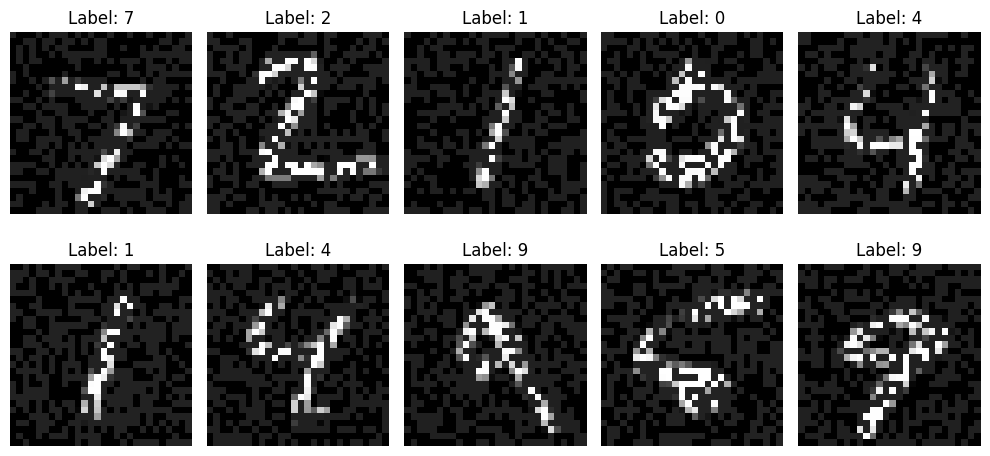

In [45]:
drop_prob = 0.5
drop_mask = np.random.rand(*test_images_cnn.shape) > drop_prob
test_images_dropped = test_images_cnn * drop_mask
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = test_images_dropped[i, :, :, 0]
    img_display = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img_display, cmap='gray')
    plt.title(f"Label: {test_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.savefig('../output/sample_images_dropped.png', dpi=150)
plt.show()


In [46]:
from tensorflow.keras import layers, models

drop_prob = 0.5
model = models.Sequential([
    layers.Conv2D(
        filters=32, 
        kernel_size=(3, 3),
        activation='relu', 
        input_shape=(28, 28, 1)
        ),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(drop_prob),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(drop_prob),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(drop_prob),
    layers.Dense(10, activation='softmax')
])  
model.summary()


/workspace/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
epochs = 10  
batch_size = 200
learn_rate = 0.001

fit_model = model.fit(
    test_images_cnn,
    test_labels,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    validation_split = 0.2
    )

print(f"Final training accuracy: {fit_model.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {fit_model.history['val_accuracy'][-1]:.4f}")
print(f"Final training loss: {fit_model.history['loss'][-1]:.4f}")
print(f"Final validation loss: {fit_model.history['val_loss'][-1]:.4f}")

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.4252 - loss: 1.6747 - val_accuracy: 0.8705 - val_loss: 0.6906
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7490 - loss: 0.7600 - val_accuracy: 0.9445 - val_loss: 0.3137
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8519 - loss: 0.4689 - val_accuracy: 0.9620 - val_loss: 0.1794
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8873 - loss: 0.3660 - val_accuracy: 0.9690 - val_loss: 0.1291
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9093 - loss: 0.2950 - val_accuracy: 0.9740 - val_loss: 0.1031
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9190 - loss: 0.2579 - val_accuracy: 0.9755 - val_loss: 0.0901
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9269 - loss: 0.2243 - val_accuracy: 0.9805 - val_loss: 0.0696
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9335 - loss: 0.2046 - val_accuracy: 0.9815 - v

Pivoting parameters to get better training and validations accuracy, and training and validation loss.

In [60]:
epochs = 20  
batch_size = 64
validation_split = 0.2
learn_rate = 0.001

seed_images = test_images_cnn  # ya en (10000,28,28,1)
seed_labels = test_labels
initial_model = model 


initial_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
    )
fit_initial_model = initial_model.fit(
    seed_images, 
    seed_labels,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
    )

print(f"Final training accuracy: {fit_initial_model.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {fit_initial_model.history['val_accuracy'][-1]:.4f}")
print(f"Final training loss: {fit_initial_model.history['loss'][-1]:.4f}")
print(f"Final validation loss: {fit_initial_model.history['val_loss'][-1]:.4f}")


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9791 - loss: 0.0631 - val_accuracy: 0.9895 - val_loss: 0.0240
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9820 - loss: 0.0551 - val_accuracy: 0.9925 - val_loss: 0.0292
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9816 - loss: 0.0578 - val_accuracy: 0.9950 - val_loss: 0.0206
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9852 - loss: 0.0455 - val_accuracy: 0.9910 - val_loss: 0.0260
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9829 - loss: 0.0534 - val_accuracy: 0.9920 - val_loss: 0.0259
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9834 - loss: 0.0545 - val_accuracy: 0.9905 - val_loss: 0.0248
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9820 - loss: 0.0479 - val_accuracy: 0.9925 - val_loss: 0.0269
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9859 - loss: 0.0446 - val_accuracy:

In [50]:
train_images = images_extractor(trainset)  # (60000, 1, 28, 28)
initial_model.fit(
    seed_images, 
    seed_labels,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
    )

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9718 - loss: 0.0925 - val_accuracy: 0.9885 - val_loss: 0.0316
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9714 - loss: 0.0851 - val_accuracy: 0.9880 - val_loss: 0.0343
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9722 - loss: 0.0838 - val_accuracy: 0.9915 - val_loss: 0.0293
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9705 - loss: 0.0845 - val_accuracy: 0.9870 - val_loss: 0.0324
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9736 - loss: 0.0831 - val_accuracy: 0.9900 - val_loss: 0.0323
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9743 - loss: 0.0833 - val_accuracy: 0.9910 - val_loss: 0.0264
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9783 - loss: 0.0706 - val_accuracy: 0.9885 - val_loss: 0.0309
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9765 - loss: 0.0678 - val_accuracy

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


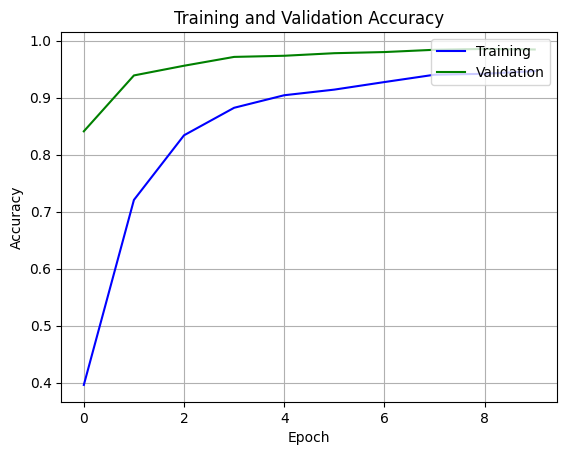

In [17]:
import matplotlib.pyplot as plt

_ = model.predict(test_images_cnn[:1])

plt.plot(fit_model.history['accuracy'], c="b", label='Train Accuracy')
plt.plot(fit_model.history['val_accuracy'], c="g", label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.savefig('../output/accuracy_plot.png', dpi=150)
plt.show()

# Evaluation

In [65]:
ACC = model.evaluate(test_images_cnn, test_labels, verbose=0)
print(f"Test accuracy: {ACC[1]:.4f}")


Test accuracy: 0.9988


# Embedding

In [ ]:
import tensorflow as tf

layer_names = [layer.name for layer in initial_model.layers]
print(layer_names)

dense_layers = [layer.name for layer in initial_model.layers 
                if isinstance(layer, tf.keras.layers.Dense)]
print("Available Dense layzers:", dense_layers)


['conv2d_2', 'max_pooling2d_2', 'dropout_3', 'conv2d_3', 'max_pooling2d_3', 'dropout_4', 'flatten_1', 'dense_2', 'dropout_5', 'dense_3']
Capas Dense disponibles: ['dense_2', 'dense_3']


In [ ]:
import tensorflow as tf

embedding_model = tf.keras.Model(
    inputs=initial_model.inputs, 
    outputs=initial_model.get_layer('dense_2').output
    )
train_embeddings = embedding_model.predict(
    train_images.reshape(-1,28,28,1)
    )  # shape (60000, 128      )

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


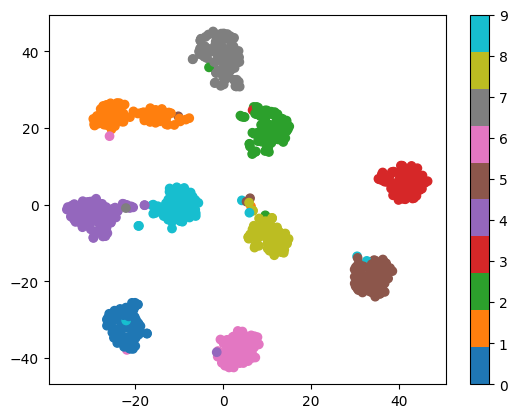

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

train_labels = labels_extractor(trainset)

tsne = TSNE(n_components=2)
embeddings_2d = tsne.fit_transform(train_embeddings[:1000])  # Only first n-ones

plt.scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    c=train_labels[:1000], 
    cmap='tab10'
    )
plt.colorbar()
plt.show()

Every point is the 2d-projection from `dense_2` layer within the initial model. We can already see the digits by their colours and how for instance `4` and `9` are way too close and the model may be confused about those labels (the result labels). 

So this is a visualization that allows us to understand _how good the model is acting_, and the overlappings will be the places where I shall take attention to. 